## Import TensorFlow and other libraries

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2
import mediapipe as mp
from itertools import combinations

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed
from typing import NamedTuple

2023-04-28 15:30:06.519687: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-28 15:30:06.570039: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-28 15:30:07.363830: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/rafael/.local/lib/python3.10/site-packages/cffi/cparser.py:163: UserWarning: Global variable 'stderr' in cdef(): for consistency with C it should have a storage class specifier (usually 'extern')
  warnings.warn("Global variable '%s' in cdef():

In [2]:
COHERENCE_LOSS = None
MAIN_LOSS = None
LANDMARKS_LOSS = "l2"
LANDMARKS_COHERENCE_LOSS = None

# Dimensions
BATCH_SIZE = 2
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 1000
LAMBDA4 = 200

VIDEOS_FOLDER = 'mug_preprocessed'

In [3]:
location = './output/cachedir'
memory = Memory(location, verbose=0)

## Load the dataset

In [4]:
videos_path = list(Path(f'../data/{VIDEOS_FOLDER}/').glob('**/*.npy'))

In [5]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [6]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

## Build an input pipeline with `tf.keras.utils.Sequence`

In [7]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

722
310


2023-04-28 15:30:10.259473: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13948 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


In [8]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        self.current_video_index += 1
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+1]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-1]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+1 < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+1 < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += 1 # Frame index start at one because we have to return the previous frame
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [9]:
train_generator = FrameDataGenerator(train_paths, batch_size=BATCH_SIZE)
test_generator = FrameDataGenerator(test_paths, batch_size=BATCH_SIZE)

previous_frame, current_frame, next_frame = next(test_generator)
tf.print(previous_frame.shape)
tf.print(current_frame.shape)
tf.print(next_frame.shape)

(2, 64, 64, 3)
(2, 64, 64, 3)
(2, 64, 64, 3)


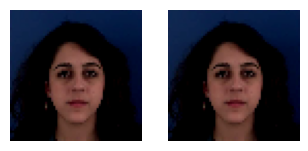

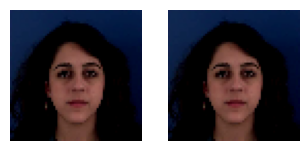

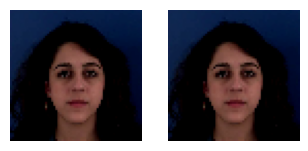

In [10]:
plot_normalized_sequence(previous_frame)
plot_normalized_sequence(current_frame)
plot_normalized_sequence(next_frame)

## Get the landmarks

In [11]:
# Grabbing the Holistic Model from Mediapipe and
# Initializing the Model
mp_holistic = mp.solutions.holistic
holistic_model = mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [12]:
def landmarks_to_array(landmarks):
    x = []
    y = []
    z = []
    for current_landmarks in landmarks:
        x.append(current_landmarks.x)
        y.append(current_landmarks.y)
        z.append(current_landmarks.z)
    return np.array([x, y, z])

def get_landmarks(clip):
    clip_landmarks = []
    for frame in clip:
        frame =  normalized_sequence_to_images(frame)
        frame = np.array(frame, dtype=np.uint8) # holistic_model expects a numpy array
        results = holistic_model.process(frame)
        if results.face_landmarks is None:
            landmarks_array = np.zeros((3, 468))
            clip_landmarks.append(landmarks_array)
        else:
            landmarks_array = landmarks_to_array(results.face_landmarks.landmark)
            clip_landmarks.append(landmarks_array)
    clip_landmarks = np.array(clip_landmarks)
    clip_landmarks = np.moveaxis(clip_landmarks, 1, 2)
    return clip_landmarks

# https://stackoverflow.com/questions/65321954/tensorflow-custom-preprocessing-with-tf-py-function-losing-shape
@tf.function
def get_tensor_landmarks(clip):
    clip_shape = clip.shape
    [results,] = tf.py_function(get_landmarks, [clip], Tout=[tf.float32])
    results = tf.convert_to_tensor(results, dtype=tf.float32)
    results.set_shape((clip_shape[0], 468, 3))
    return results

In [13]:
current_frames_landmarks = get_tensor_landmarks(current_frame)
tf.print(current_frame.shape)
tf.print(current_frames_landmarks.shape) # (batch, landmarks, (x,y,z))
tf.print(current_frames_landmarks[0,0])

(2, 64, 64, 3)
TensorShape([2, 468, 3])
[0.509672582 0.682688117 -0.0597787835]


In [14]:
@tf.function
def euclidean_distance(a, b):
  return tf.math.sqrt(tf.math.reduce_sum(tf.math.pow(a-b, 2), axis=-1))

@tf.function
def all_pairs_distances(x):
  x = tf.reshape(x, (-1, x.shape[-1]))
  indices = tf.stack(list(combinations(range(len(x)), 2)))
  a_index = indices[:,0]
  b_index = indices[:,1]
  a = tf.gather(x, a_index)
  b = tf.gather(x, b_index)
  return euclidean_distance(a,b)


@tf.function
def l1_loss(previous, current):
  return  tf.math.abs(current-previous)

@tf.function
def pairwise_loss(y_true, y_pred):
  y_true = all_pairs_distances(y_true)
  y_pred = all_pairs_distances(y_pred)
  return tf.math.reduce_mean(euclidean_distance(y_true, y_pred))

@tf.function
def get_luminance(image):
  output = normalized_sequence_to_images(image)
  output = tfio.experimental.color.rgb_to_ycbcr(output)
  output = output[...,0] # get y from ycbcr
  return tf.cast(output, tf.float32)

@tf.function
def apply_luminance_loss(previous, current, loss_function):
  previous_luminance = get_luminance(previous)
  current_luminance = get_luminance(current)
  return loss_function(previous_luminance, current_luminance)

@tf.function
def mean_loss(y_true, y_pred, loss_function):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  return tf.math.reduce_mean(loss_function(y_true, y_pred))

@tf.function
def coherence_mean_loss(previous_y_true, y_true, previous_y_pred, y_pred, loss_function):
  loss_true = apply_luminance_loss(previous_y_true, y_true, loss_function)
  loss_pred = apply_luminance_loss(previous_y_pred, y_pred, loss_function)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

@tf.function
def coherence_mean_landmarks_loss(previous_y_true_landmarks, y_true_landmarks, previous_y_pred_landmarks, y_pred_landmarks, loss_function):
  loss_true = loss_function(previous_y_true_landmarks, y_true_landmarks)
  loss_pred = loss_function(previous_y_pred_landmarks, y_pred_landmarks)
  return tf.math.reduce_mean(tf.abs(loss_true - loss_pred))

## Find similar

In [15]:
def subject_from_path(path):
    if len(path.parents) == 8:
        return path.parents[3].name
    else:
        return path.parents[2].name

def expression_from_path(path):
    return path.parents[1].name

class FirstFrameDataGenerator(FrameDataGenerator):

    def __init__(self, videos_path, batch_size=1):
        super().__init__(videos_path, batch_size)
        self.current_video_index = -1

    def _load_next_video(self):
        self.current_frame_index = 0
        self.current_video_index += 1
        self._load_current_video()
    
    def _subject(self):
        return subject_from_path(self.videos_path[self.current_video_index])
    
    def _expression(self):
        return expression_from_path(self.videos_path[self.current_video_index])
    
    def _first_frame(self):
        return self.current_video[0]

    def _has_three_frames(self):
        return self.current_video.shape[0] > 2

    def __next__(self):
        if self._has_next_video():
            self._load_next_video()
        else:
            self._end_of_videos()
        while not self._has_three_frames(): # A useful video must have previous, current and next frames
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._first_frame(), self._subject(), self._expression()

In [16]:
def first_frame_data(generator):
    data = list(generator)
    frames = []
    subjects = []
    expressions = []
    for frame, subject, expression in data:
        frames.append(frame)
        subjects.append(subject)
        expressions.append(expression)
    return np.array(frames), np.array(subjects), np.array(expressions)

In [17]:
train_first_generator = FirstFrameDataGenerator(train_paths)
test_first_generator = FirstFrameDataGenerator(test_paths)

train_first_frames, train_subjects, train_expressions = first_frame_data(train_first_generator)
test_first_frames, test_subjects, test_expressions = first_frame_data(test_first_generator)

print(train_first_frames.shape)
print(len(train_subjects))
print(len(train_expressions))
print(test_first_frames.shape)
print(len(test_subjects))
print(len(test_expressions))

(722, 64, 64, 3)
722
722
(310, 64, 64, 3)
310
310


In [19]:
def get_all_pairs_distances_for_dataset(first_frame_dataset):
  distances_dataset = []
  for current_frame in tqdm(first_frame_dataset):
    current_frame = tf.expand_dims(current_frame, axis=0)
    current_frame_landmarks = get_tensor_landmarks(current_frame)
    current_frame_distances = all_pairs_distances(current_frame_landmarks)
    distances_dataset.append(current_frame_distances)
  return tf.stack(distances_dataset)

train_distances_dataset = get_all_pairs_distances_for_dataset(train_first_frames)
test_distances_dataset = get_all_pairs_distances_for_dataset(test_first_frames)

  0%|          | 0/722 [00:00<?, ?it/s]

  0%|          | 0/310 [00:00<?, ?it/s]

In [20]:
def most_similar_subject(search_frame, search_subject, distances_dataset, subjects_dataset):
  exclude_index = subjects_dataset!=search_subject
  distances_dataset = distances_dataset[exclude_index]
  subjects_dataset = subjects_dataset[exclude_index]
  search_frame = tf.expand_dims(search_frame, axis=0)
  search_frame_landmarks = get_tensor_landmarks(search_frame)
  search_frame_distances = all_pairs_distances(search_frame_landmarks)
  loss_values = []
  for current_distances in distances_dataset:
    loss_value = tf.math.reduce_mean(euclidean_distance(search_frame_distances, current_distances))
    loss_values.append(loss_value)
  loss_values = tf.stack(loss_values)
  return subjects_dataset[tf.math.argmin(loss_values)]

def first_index_from_subject(subject, subjects_dataset):
  return np.where(subjects_dataset==subject)[0][0]

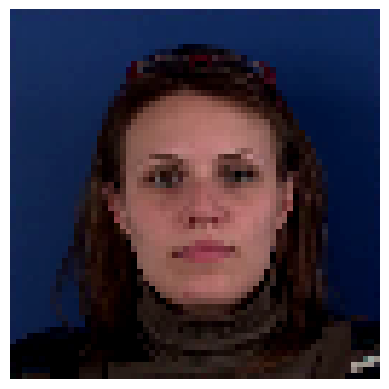

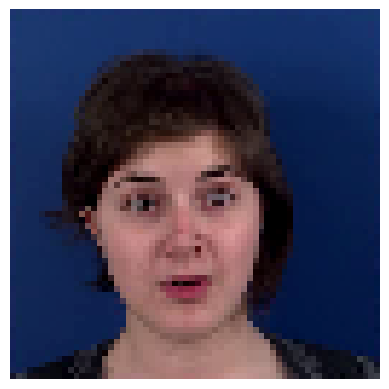

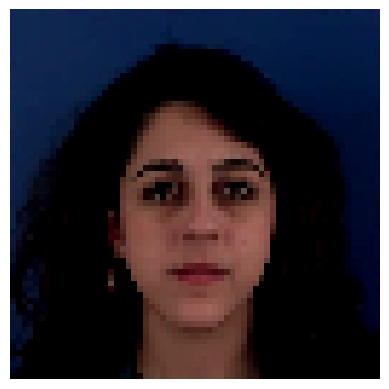

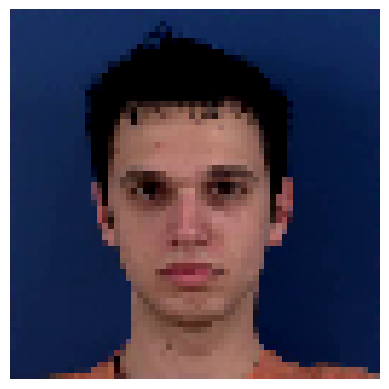

075 048


In [21]:
ex_train_frame, ex_train_subject, ex_train_expression = train_first_frames[0], train_subjects[0], train_expressions[0]
ex_test_frame, ex_test_subject, ex_test_expression = test_first_frames[0], test_subjects[0], test_expressions[0]
train_most_similar_subject = most_similar_subject(ex_train_frame, ex_train_subject, train_distances_dataset, train_subjects)
train_most_similar_index = first_index_from_subject(train_most_similar_subject, train_subjects)
plot_normalized_frame(ex_train_frame)
plot_normalized_frame(train_first_frames[train_most_similar_index])
test_most_similar_subject = most_similar_subject(ex_test_frame, ex_test_subject, test_distances_dataset, test_subjects)
test_most_similar_index = first_index_from_subject(test_most_similar_subject, test_subjects)
plot_normalized_frame(ex_test_frame)
plot_normalized_frame(test_first_frames[test_most_similar_index])
print(ex_train_subject, train_subjects[train_most_similar_index])

In [22]:
def get_all_most_similar_subjects(search_frames, search_subjects, distances_dataset, subjects_dataset):
    all_most_similar_subjects = []
    search_subjects = set(search_subjects)
    for i in tqdm(range(len(search_frames))):
        all_most_similar_subjects.append(most_similar_subject(search_frames[i], search_subjects[i], distances_dataset, subjects_dataset))
    return np.array(all_most_similar_subjects)

In [24]:
print(train_subjects)
print(set(train_subjects))

['075' '075' '075' '075' '075' '075' '075' '075' '075' '075' '075' '075'
 '075' '075' '075' '075' '075' '075' '075' '075' '075' '075' '075' '048'
 '048' '048' '048' '048' '048' '048' '048' '048' '048' '048' '048' '048'
 '048' '048' '048' '048' '048' '048' '048' '048' '048' '046' '046' '046'
 '046' '046' '046' '046' '046' '046' '046' '046' '046' '046' '046' '046'
 '046' '046' '046' '046' '046' '046' '061' '061' '061' '061' '061' '061'
 '061' '061' '061' '061' '061' '061' '061' '061' '061' '061' '061' '066'
 '066' '066' '066' '066' '066' '066' '066' '066' '066' '066' '066' '066'
 '066' '066' '066' '066' '066' '066' '066' '030' '030' '030' '030' '030'
 '030' '030' '030' '030' '030' '030' '030' '030' '030' '030' '030' '030'
 '030' '030' '030' '030' '030' '030' '038' '038' '038' '038' '038' '038'
 '038' '038' '038' '038' '038' '038' '038' '038' '038' '038' '038' '038'
 '073' '073' '073' '073' '073' '073' '073' '073' '073' '073' '073' '073'
 '073' '073' '073' '073' '073' '073' '073' '073' '0

In [25]:
all_most_similar_test_subjects = get_all_most_similar_subjects(test_first_frames, test_subjects, test_distances_dataset, test_subjects)
print(all_most_similar_test_subjects)
all_most_similar_test_subjects.save('data/mug_test_similar_subjects.npy')

  0%|          | 0/310 [00:00<?, ?it/s]

TypeError: 'set' object is not subscriptable

In [ ]:
all_most_similar_train_subjects = get_all_most_similar_subjects(train_first_frames, train_subjects, train_distances_dataset, train_subjects)
print(all_most_similar_train_subjects)
all_most_similar_train_subjects.save('data/mug_train_similar_subjects.npy')